# **Systèmes de Recherche d'Images par le Contenu - Approche Deep"**

La recherche d'images basée sur le contenu consiste à retrouver dans une base de données les images visuellement similaires à une image donnée, en se basant sur leurs caractéristiques visuelles.
Avec l’essor de l’apprentissage profond, les méthodes CBIR ont considérablement évolué. Les réseaux neuronaux permettent désormais d’extraire des descripteurs riches et discriminants, capturant à la fois des détails locaux et des informations sémantiques globales.

Dans ce projet, nous allons comparer deux approches principales pour l’extraction de features en CBIR :

1. **Réseau CNN pré-entraîné** (VGG16, ResNet50, etc) :  
   - Utilisé comme extracteur de caractéristiques.  
   - Les couches profondes fournissent des représentations hiérarchiques des images (bords, textures) à des concepts plus complexes.  

2. **Autoencodeur profond** :  
   - Apprend à encoder une image dans un code latent compact puis à la reconstruire.  
   - Le code latent est utilisé comme vecteur de descripteur
  
  **Objectifs du TP :**  

- Charger et prétraiter la base d’images fournie
- Utiliser un CNN pré-entraîné pour extraire des descripteurs  
- Construire et entraîner un autoencodeur profond
- Définir une métrique de similarité (cosine ou euclidienne)  
- Effectuer des recherches CBIR et afficher les images les plus similaires à une image requête  
- Visualiser les feature maps pour comprendre les représentations apprises par chaque type de réseau  



# **2. Importer les librairies nécessaires**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

from PIL import Image
import cv2
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input as preprocess_vgg
from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_resnet
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.preprocessing.image import img_to_array, load_img

print("TensorFlow version:", tf.__version__)

Mounted at /content/drive
TensorFlow version: 2.19.0


# **3. Chargement et prétraitement des images**

La base Corel contient 100 images divisées en 10 classes. La base est déjà divisée en train et test. Les images doivent être prétraitées selon le modèle utilisé.

Afficher quelques images aléatoires pour vérifier que le chargement est correct.

In [2]:
base_dir = "/content/drive/MyDrive/DeepCBIR_Dataset"
for root, dirs, files in os.walk(base_dir):
    print(root, ":", len(files), "images")

/content/drive/MyDrive/DeepCBIR_Dataset : 0 images
/content/drive/MyDrive/DeepCBIR_Dataset/training_set : 0 images
/content/drive/MyDrive/DeepCBIR_Dataset/training_set/bus : 90 images
/content/drive/MyDrive/DeepCBIR_Dataset/training_set/beaches : 90 images
/content/drive/MyDrive/DeepCBIR_Dataset/training_set/elephants : 90 images
/content/drive/MyDrive/DeepCBIR_Dataset/training_set/dinosaurs : 90 images
/content/drive/MyDrive/DeepCBIR_Dataset/training_set/flowers : 90 images
/content/drive/MyDrive/DeepCBIR_Dataset/training_set/foods : 90 images
/content/drive/MyDrive/DeepCBIR_Dataset/training_set/horses : 90 images
/content/drive/MyDrive/DeepCBIR_Dataset/training_set/monuments : 90 images
/content/drive/MyDrive/DeepCBIR_Dataset/training_set/mountains_and_snow : 90 images
/content/drive/MyDrive/DeepCBIR_Dataset/training_set/peolpe_and_villages_in_Africa : 90 images
/content/drive/MyDrive/DeepCBIR_Dataset/test_set : 0 images
/content/drive/MyDrive/DeepCBIR_Dataset/test_set/beaches : 10 i

In [39]:
img_height = 224
img_width = 224
batch_size = 8

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    base_dir + "/training_set",
    labels="inferred",
    label_mode="categorical",
    batch_size=batch_size,
    image_size=(img_height, img_width),
    shuffle=True,
    seed=123
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    base_dir + "/test_set",
    labels="inferred",
    label_mode="categorical",
    batch_size=batch_size,
    image_size=(img_height, img_width),
    shuffle=False
)

Found 900 files belonging to 10 classes.
Found 100 files belonging to 10 classes.


Les images sont prétraitées selon le modèle **VGG16**.

**Choix du modèle:**
- **Simplicité** : Son architecture est simple et uniforme.
- **Performance** : Sur notre ensemble de données spécifique, VGG16 peut être une option plus performante que ResNet50, car des couches personnalisées ont été ajoutées pour l'identifier, comme le rapporte cet article de l'IEEE Xplore.
- **Moins de ressources**

### VGG16 – Convolutional Network for Classification and Detection
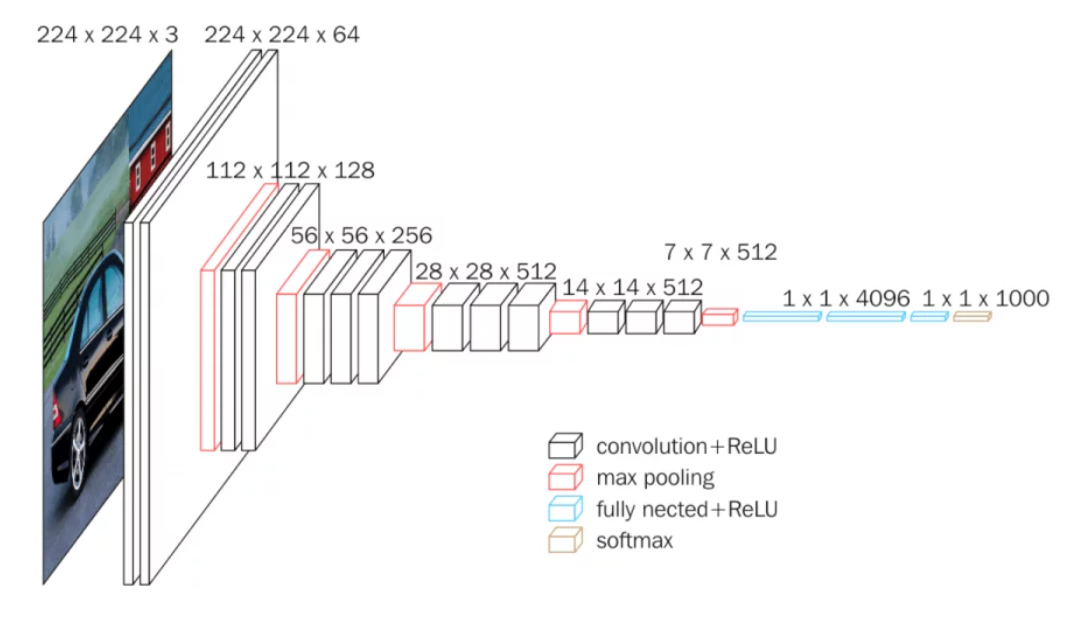

In [22]:
def preprocess_vgg_images(images, labels):
    images = tf.keras.applications.vgg16.preprocess_input(images)
    return images, labels

train_ds_preprocessed = train_ds.map(preprocess_vgg_images)
test_ds_preprocessed = test_ds.map(preprocess_vgg_images)

Quelques images aléatoires pour vérification du chargement

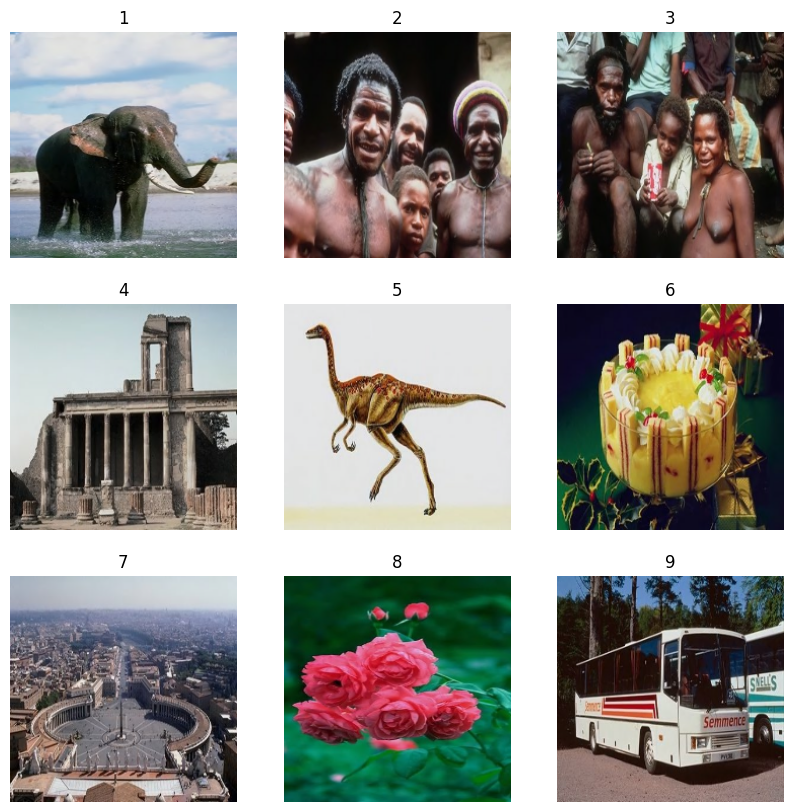

In [23]:
# ImageNet mean values for BGR channels (VGG16 preprocessing uses BGR)
# These are typically subtracted during preprocessing, so we add them back.
IMAGENET_MEAN_BGR = np.array([103.939, 116.779, 123.68])

plt.figure(figsize=(10, 10))
for images, labels in train_ds_preprocessed.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        img = images[i].numpy()

        # Reverse VGG16 preprocessing for display:
        # 1. Add ImageNet means (since they were subtracted).
        # 2. Convert from BGR to RGB (VGG16 preprocess_input converts to BGR).
        # 3. Clip values to be in [0, 255] range and convert to uint8.
        img_display = img + IMAGENET_MEAN_BGR
        img_display = img_display[:, :, ::-1] # Convert BGR to RGB
        img_display = np.clip(img_display, 0, 255).astype("uint8")

        plt.imshow(img_display)
        plt.title(i+1)
        plt.axis("off")
plt.show()

# **4. CNN Pré-entraîné sur la base ImageNet**
# Construction du Feature Extractor

Utiliser un CNN pré-entraîné comme extracteur de features, charger le modèle (VGG16, ResNet50..) avec `weights='imagenet'`, retirer la couche de classification (include_top=False). Le modèle doit être non entraînable(`trainable=False`)


In [24]:
# Charger VGG16 pré-entraîné non entraînable sur ImageNet
# include_top=False → enlève les couches fully-connected
# pooling='avg' → génère un vecteur global de caractéristiques
base_model = VGG16(weights='imagenet', include_top=False, pooling='avg')
base_model.trainable = False

print("Architecture prête — dimension du vecteur de features :", base_model.output_shape)

Architecture prête — dimension du vecteur de features : (None, 512)


→ Cela produit un vecteur de dimension 512 pour chaque image, idéal pour la recherche CBIR.

# Extraction des descripteurs CNN
Générer pour chaque image un vecteur de caractéristiques

In [25]:
def extract_features(dataset, model):
    features = []
    labels = []

    for batch_images, batch_labels in tqdm(dataset):
        batch_features = model.predict(batch_images)
        features.append(batch_features)
        labels.append(batch_labels)

    return np.vstack(features), np.vstack(labels)

train_features, train_labels = extract_features(train_ds_preprocessed, base_model)
test_features, test_labels = extract_features(test_ds_preprocessed, base_model)

print("Train features :", train_features.shape)
print("Test features :", test_features.shape)

  0%|          | 0/29 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


  3%|▎         | 1/29 [00:01<00:40,  1.43s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step


  7%|▋         | 2/29 [00:01<00:20,  1.31it/s]

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step


 75%|███████▌  | 3/4 [00:01<00:00,  2.62it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


100%|██████████| 4/4 [00:01<00:00,  2.73it/s]

Train features : (900, 512)
Test features : (100, 512)


# Visualisation des Feature Maps
Comparer feature maps de différentes couches pour comprendre la hiérarchie des
représentations.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 502ms/step


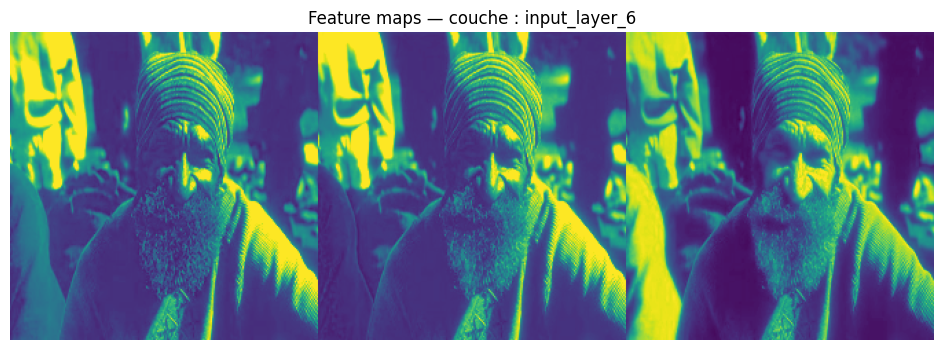

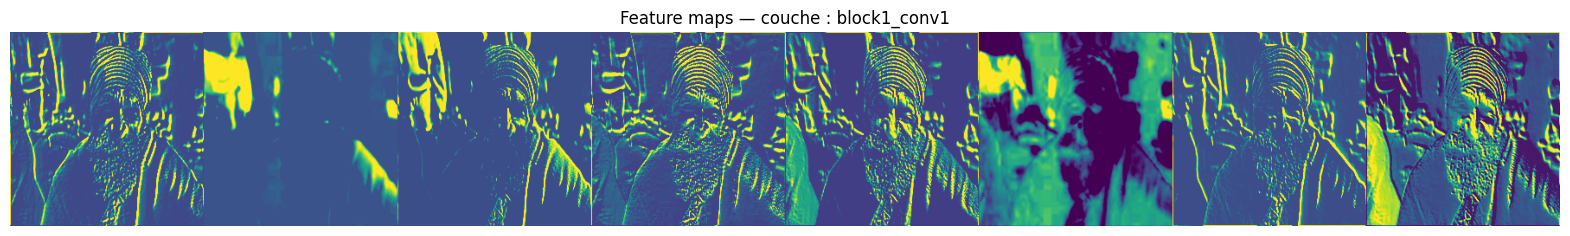

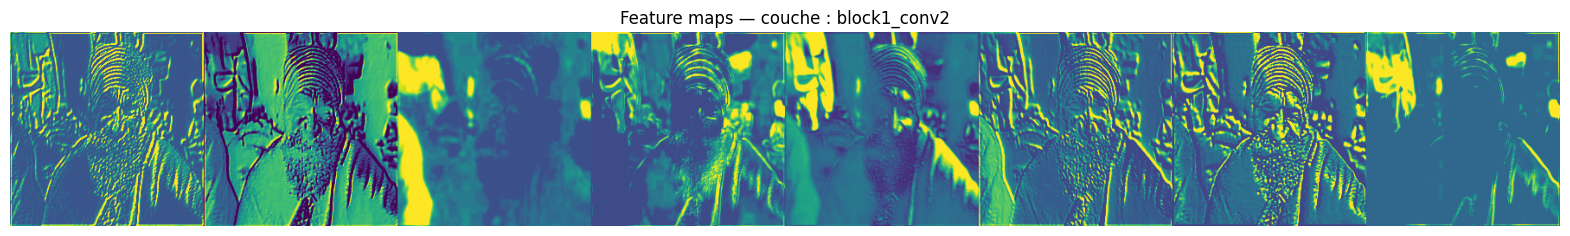

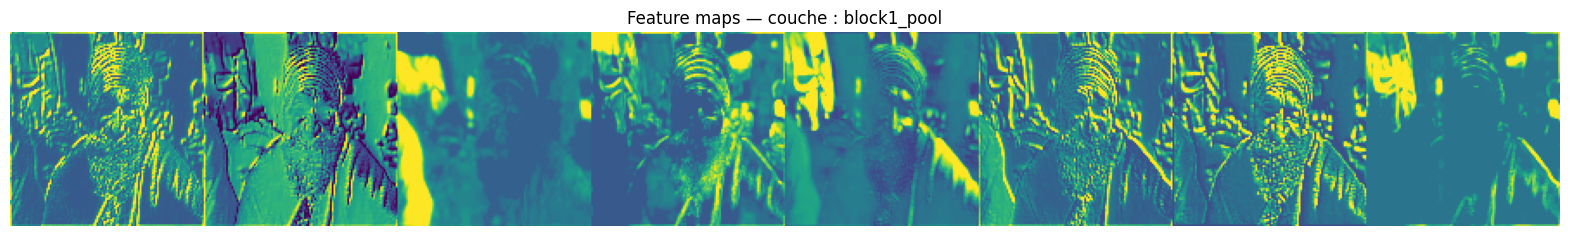

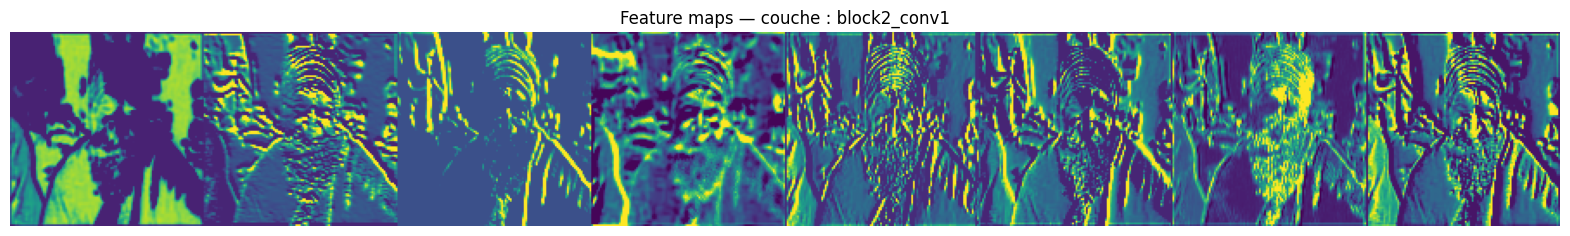

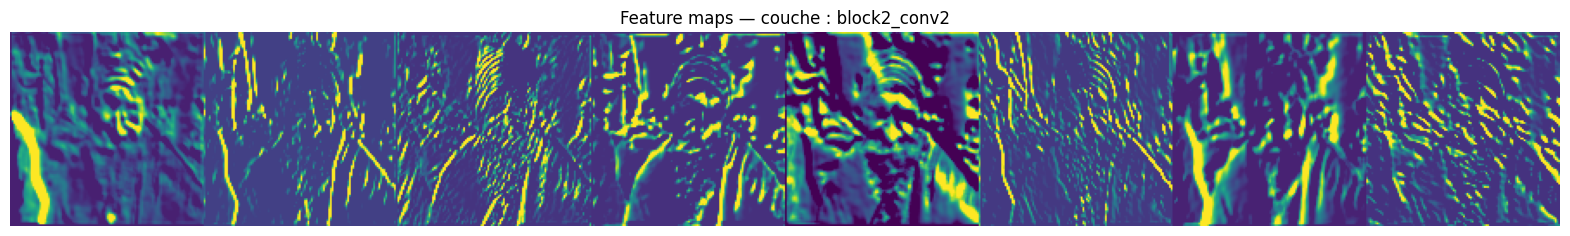

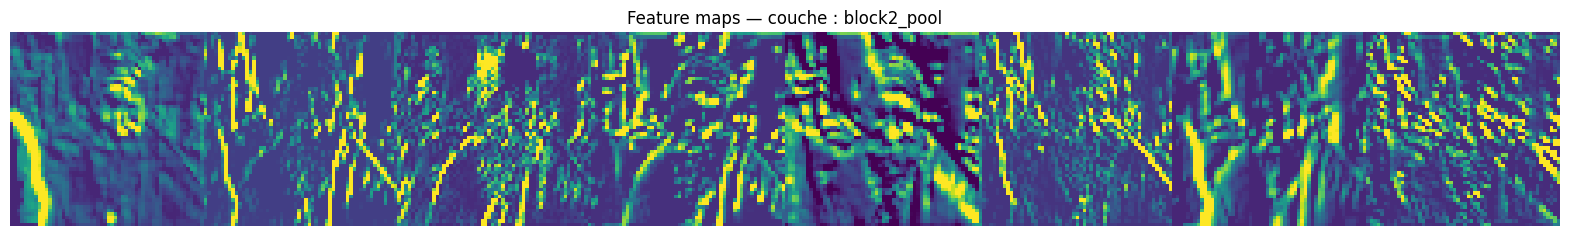

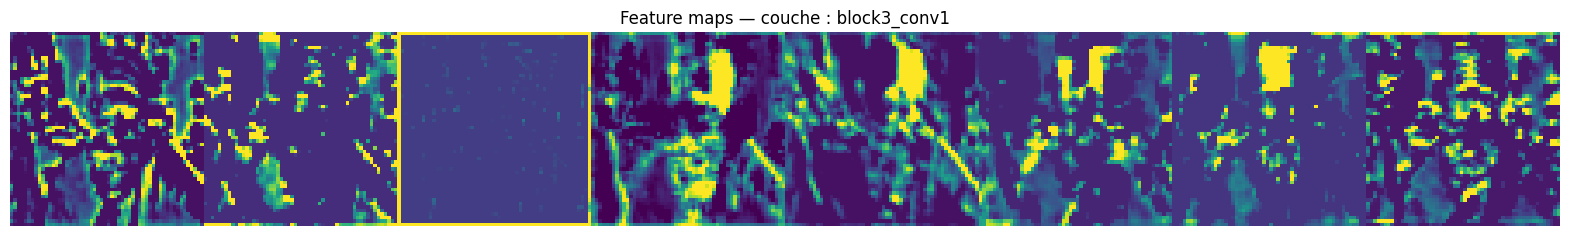

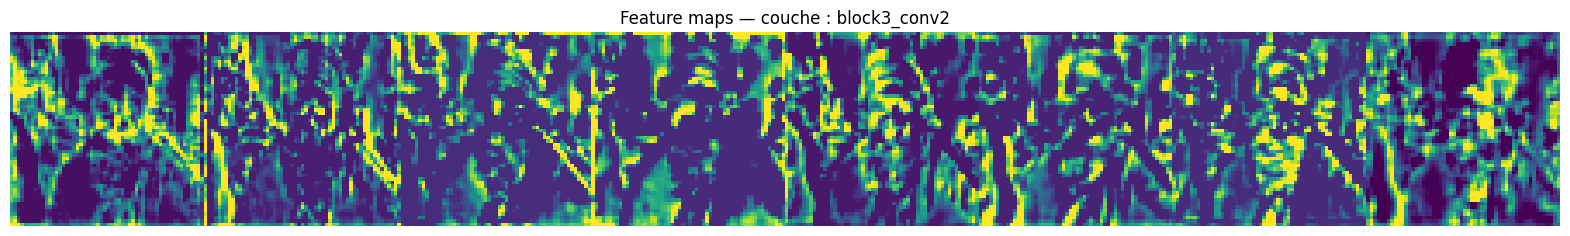

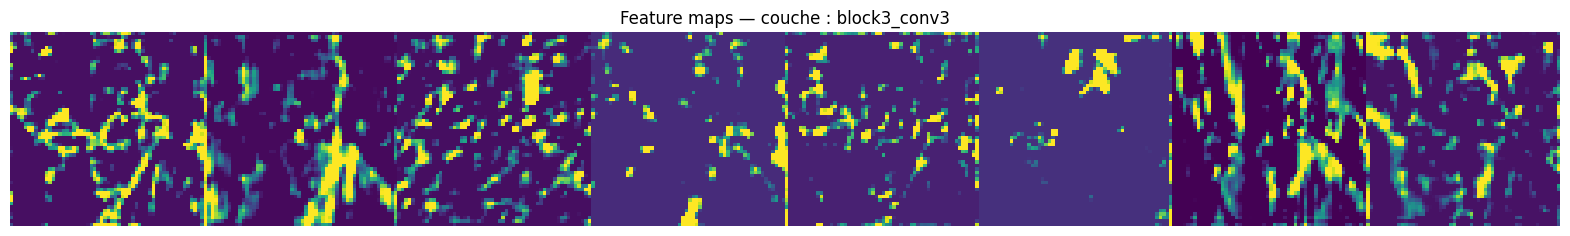

In [26]:
layer_outputs = [layer.output for layer in base_model.layers[:10]]  # les 10 premières couches
activation_model = Model(inputs=base_model.input, outputs=layer_outputs)

for imgs, _ in train_ds_preprocessed.take(1):
    sample = imgs[0]
    break

img = tf.expand_dims(sample, axis=0)

activations = activation_model.predict(img)
layer_names = [layer.name for layer in base_model.layers[:10]]

for layer_name, layer_activation in zip(layer_names, activations):
    n_features = layer_activation.shape[-1]

    # Only process layers with spatial dimensions and features
    if len(layer_activation.shape) == 4 and n_features > 0:
        size = layer_activation.shape[1]
        num_features_to_display = min(n_features, 8) # max 8
        display_grid = np.zeros((size, size * num_features_to_display))

        for i in range(num_features_to_display):
            feature_map = layer_activation[0, :, :, i]

            # Normalize feature map for better visualization
            feature_map -= feature_map.mean()
            std_dev = feature_map.std()
            if std_dev != 0: # for constant feature maps
                feature_map /= std_dev
            else:
                feature_map = np.zeros_like(feature_map)

            feature_map *= 64
            feature_map += 128
            feature_map = np.clip(feature_map, 0, 255).astype("uint8")
            display_grid[:, i * size : (i + 1) * size] = feature_map

        plt.figure(figsize=(20, 4))
        plt.imshow(display_grid, cmap='viridis')
        plt.title(f"Feature maps — couche : {layer_name}")
        plt.axis("off")
        plt.show()
    else:
        print(f"Skipping layer {layer_name} as it does not have enough features or spatial dimensions to visualize.")

**Observations:**
- Couches proches de l’entrée (block1_conv1, block1_conv2) : détectent les bords, gradients, textures simples
- Couches intermédiaires (block2_conv1, block2_conv2) : motifs plus complexes (coins, motifs répétitifs)
- Couches profondes : représentation abstraite, utile pour CBIR

# **5. Autoencodeur profond**

# Build Autoencoder
- Encoder : plusieurs couches Conv2D + MaxPooling2D + Flatten + Dense(code_size)

- Decoder : Dense + Reshape + Conv2DTranspose pour reconstruire l'image

- Le modèle final prend une image en entrée et la reconstruit

## Encoder

In [40]:
code_size = 256
inputs = Input(shape=(224, 224, 3))

x = Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2), padding='same')(x)

shape_before_flattening = x.shape[1:]  # pour le decoder
x = Flatten()(x)

encoded = Dense(code_size, activation='relu')(x)

encoder = Model(inputs, encoded, name="Encoder")
encoder.summary()

Model: "Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │    25,690,368 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,783,616 (98.36 MB)

 Trainable params: 25,783,616 (98.36 MB)

 Non-trainable params: 0 (0.00 B)

## Decoder

In [41]:
from tensorflow.keras.layers import Reshape, Conv2DTranspose

decoder_input = Input(shape=(code_size,))

x = Dense(np.prod(shape_before_flattening))(decoder_input)
x = Reshape(shape_before_flattening)(x)

x = Conv2DTranspose(128, (3,3), strides=1, activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

x = Conv2DTranspose(64, (3,3), strides=1, activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

x = Conv2DTranspose(32, (3,3), strides=1, activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)

decoder = Model(decoder_input, decoded, name="Decoder")
decoder.summary()

Model: "Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 100352)         │    25,790,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_6              │ (None, 28, 28, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_6 (UpSampling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_7              │ (None, 56, 56, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_7 (UpSampling2D)  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_8              │ (None, 112, 112, 32)   │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_8 (UpSampling2D)  │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 224, 224, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,031,171 (99.30 MB)

 Trainable params: 26,031,171 (99.30 MB)

 Non-trainable params: 0 (0.00 B)

## Autoencodeur

In [42]:
autoencoder_input = inputs
autoencoder_output = decoder(encoded)

autoencoder = Model(autoencoder_input, autoencoder_output, name="Autoencoder")

autoencoder.build(input_shape=(None, 224, 224, 3))

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder (Functional)            │ (None, 224, 224, 3)    │    26,031,171 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,814,787 (197.66 MB)

 Trainable params: 51,814,787 (197.66 MB)

 Non-trainable params: 0 (0.00 B)

In [50]:
def normalize_for_ae(images, labels):
    images = tf.cast(images, tf.float32) / 255.0
    return images, images  # input = output pour l'autoencoder

ae_train_ds = train_ds.map(normalize_for_ae)
ae_test_ds  = test_ds.map(normalize_for_ae)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.05),
])
ae_train_ds_aug = ae_train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

history = autoencoder.fit(
    ae_train_ds_aug,
    validation_data=ae_test_ds,
    epochs=20
)

Epoch 1/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 12s 105ms/step - loss: 0.0240 - val_loss: 0.0360
Epoch 2/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 12s 104ms/step - loss: 0.0241 - val_loss: 0.0365
Epoch 3/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 12s 105ms/step - loss: 0.0221 - val_loss: 0.0370
Epoch 4/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 12s 105ms/step - loss: 0.0219 - val_loss: 0.0373
Epoch 5/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 12s 102ms/step - loss: 0.0201 - val_loss: 0.0385
Epoch 6/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 11s 95ms/step - loss: 0.0199 - val_loss: 0.0383
Epoch 7/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 12s 102ms/step - loss: 0.0196 - val_loss: 0.0373
Epoch 8/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 12s 105ms/step - loss: 0.0182 - val_loss: 0.0382
Epoch 9/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 21s 105ms/step - loss: 0.0180 - val_loss: 0.0379
Epoch 10/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 12s 106ms/step - loss: 0.0177 - val_loss: 0.0382
Epoch 11/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 11s 100ms/step - loss: 0.0168 - val_loss: 0.0382
Epoch 12/20
113/113 

# Extraction des descripteurs

In [52]:
def dataset_to_numpy(dataset):
    images = []
    for batch, _ in dataset:
        images.append(batch.numpy())
    return np.vstack(images)

X_train_np = dataset_to_numpy(ae_train_ds)  # training images
X_test_np  = dataset_to_numpy(ae_test_ds)   # test images

print("\nX_train_np.shape =", X_train_np.shape)
print("X_test_np.shape  =", X_test_np.shape)

descriptors_train = encoder.predict(X_train_np)
descriptors_test  = encoder.predict(X_test_np)

print("\ndescriptors_train.shape =", descriptors_train.shape)
print("descriptors_test.shape  =", descriptors_test.shape)


X_train_np.shape = (900, 224, 224, 3)
X_test_np.shape  = (100, 224, 224, 3)
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

descriptors_train.shape = (900, 256)
descriptors_test.shape  = (100, 256)


# Visualisation du vecteur latent de l’autoencodeur
- Comprendre ce que l'encodeur a appris pour représenter l'image

- Afficher le vecteur code latent produit par l'encodeur

- Comparer avec l'image reconstruite par le decoder

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Latent vector shape: (1, 256)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Reconstructed image shape: (1, 224, 224, 3)


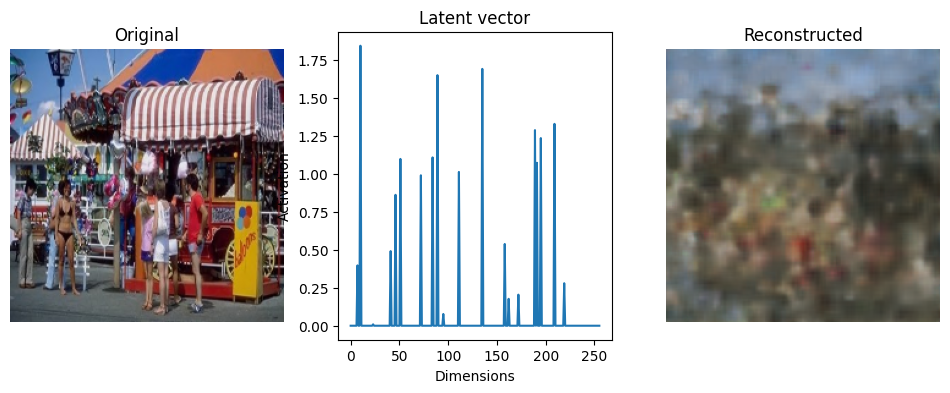

In [54]:
sample_idx = 0
sample_image = X_test_np[sample_idx:sample_idx+1]  # shape (1, 224, 224, 3)

# Encode the image
latent_vector = encoder.predict(sample_image)  # shape (1, code_size)
print("Latent vector shape:", latent_vector.shape)

# Reconstruct the image using the decoder
reconstructed_image = decoder.predict(latent_vector)
print("Reconstructed image shape:", reconstructed_image.shape)

# Visualize the results
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(sample_image[0])
plt.title("Original")
plt.axis("off")

# Latent vector
plt.subplot(1, 3, 2)
plt.plot(latent_vector[0])
plt.title("Latent vector")
plt.xlabel("Dimensions")
plt.ylabel("Activation")

# Reconstructed image
plt.subplot(1, 3, 3)
plt.imshow(reconstructed_image[0])
plt.title("Reconstructed")
plt.axis("off")

plt.show()

* Chaque dimension du vecteur encode des caractéristiques abstraites de l’image : bords, textures, couleurs, formes.
* Même si le décodeur ne reconstruit pas fidèlement l’image, le vecteur latent contient l’information essentielle que l’encodeur considère comme importante.
* La reconstruction est mauvaise pour plusieurs facteurs :
  * Code latent trop petit : 256 dimensions peuvent ne pas suffire pour recréer une image 224×224 complexe.
  * Architecture du décodeur pas assez profonde pour restituer les détails fins.

MAIS une reconstruction imparfaite n’est pas un problème pour CBIR, car l’objectif n’est pas de recréer parfaitement l’image mais de générer un vecteur latent discriminant.

# **Recherche d’images similaires**

 - Comprendre comment utiliser les vecteurs descripteurs  pour rechercher des images proches dans une base.

- Comparer les performances de l’autoencodeur et du CNN pré-entraîné. Choisir la fonction distance ou similarité (cosine, distance euclidienne)

- Visualiser les résultats pour une image requête.

### Choix de la métrique

* Cosine similarity : mesure l’angle entre vecteurs, robuste aux différences d’échelle.
* Euclidean distance : distance directe dans l’espace vectoriel.

Ici, on utilisera cosine similarity, très courante pour les descripteurs d’images.

#### Recherche d’images similaires pour un vecteur latent (AE)

In [55]:
from sklearn.metrics.pairwise import cosine_similarity

query_idx = 0
query_vector = descriptors_test[query_idx].reshape(1, -1)  # vecteur latent de l'AE

# Calculer similarité cosinus avec toutes les images de train
similarities = cosine_similarity(query_vector, descriptors_train)  # shape (1, num_train)
top_k_idx = similarities[0].argsort()[-5:][::-1]  # top-5 images les plus proches

print("Indices des 5 images les plus similaires :", top_k_idx)

Indices des 5 images les plus similaires : [397 617 286 828 537]


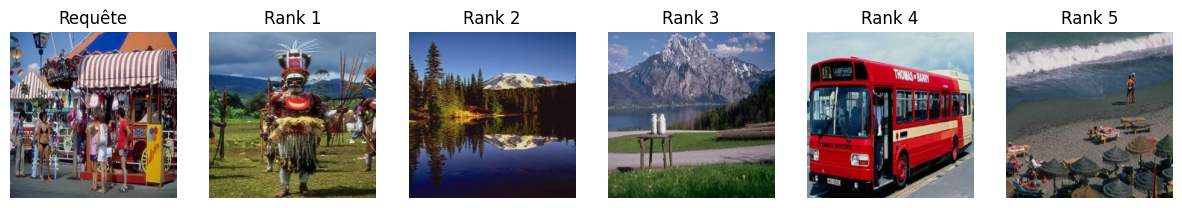

In [56]:
plt.figure(figsize=(15,4))

plt.subplot(1,6,1)
plt.imshow(X_test_np[query_idx])
plt.title("Requête")
plt.axis("off")

for i, idx in enumerate(top_k_idx):
    plt.subplot(1,6,i+2)
    plt.imshow(X_train_np[idx])
    plt.title(f"Rank {i+1}")
    plt.axis("off")
plt.show()

#### Comparaison avec VGG16

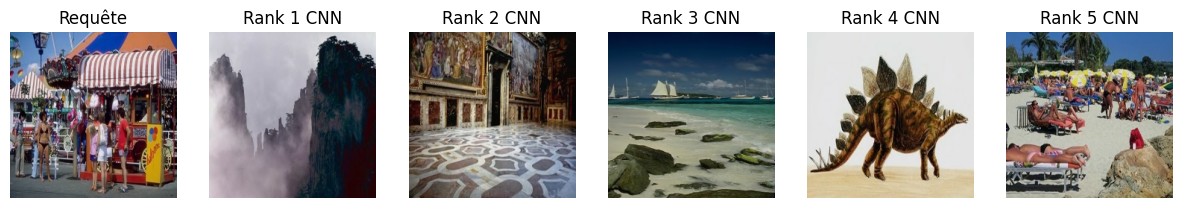

In [57]:
query_vector_cnn = test_features[query_idx].reshape(1, -1)
similarities_cnn = cosine_similarity(query_vector_cnn, train_features)
top_k_cnn = similarities_cnn[0].argsort()[-5:][::-1]

# Visualiser les résultats
plt.figure(figsize=(15,4))
plt.subplot(1,6,1)
plt.imshow(X_test_np[query_idx])
plt.title("Requête")
plt.axis("off")

for i, idx in enumerate(top_k_cnn):
    plt.subplot(1,6,i+2)
    plt.imshow(X_train_np[idx])
    plt.title(f"Rank {i+1} CNN")
    plt.axis("off")

plt.show()

### Comparaison quantitative avec Precision@k

In [58]:
def precision_at_k(query_labels, retrieved_indices, train_labels, k=5):
    retrieved_labels = train_labels[retrieved_indices][:k]
    correct = np.sum(retrieved_labels == query_labels)
    return correct / k

In [59]:
train_labels_np = np.concatenate([y.numpy() for _, y in train_ds], axis=0)
train_labels_idx = np.argmax(train_labels_np, axis=1)  # si one-hot

test_labels_np = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
test_labels_idx = np.argmax(test_labels_np, axis=1)

In [60]:
def compute_precision_at_k(descriptors_train, descriptors_test, train_labels, test_labels, k=5):
    precisions = []
    for i in range(len(test_labels)):
        query_vector = descriptors_test[i].reshape(1, -1)
        similarities = cosine_similarity(query_vector, descriptors_train)
        top_k_idx = similarities[0].argsort()[-k:][::-1]
        p = precision_at_k(test_labels[i], top_k_idx, train_labels, k)
        precisions.append(p)
    return np.mean(precisions)

In [62]:
p_at_5_ae = compute_precision_at_k(descriptors_train, descriptors_test, train_labels_idx, test_labels_idx, k=5)
print("Precision@5 (Autoencodeur) :", p_at_5_ae)

p_at_5_cnn = compute_precision_at_k(train_features, test_features, train_labels_idx, test_labels_idx, k=5)
print("Precision@5 (CNN pré-entraîné) :", p_at_5_cnn)

Precision@5 (Autoencodeur) : 0.07
Precision@5 (CNN pré-entraîné) : 0.09


L'étude quantitative montre que l'utilisation d'un CNN pré-entraîné comme VGG16 est plus efficace pour retrouver les images de même classe.